
# <span style="color:#1F4E79;">Método de iteración de punto fijo</span>
### Algoritmo 2.2 de Burden — páginas 45 y 46

**Objetivo:** implementar el método de punto fijo en Python y probarlo con el Ejemplo 1 de Burden: \(x^3+4x^2-10=0\).



## 1. Planteamiento del problema

Se busca aproximar la raíz positiva de

\[
\boxed{f(x)=x^3+4x^2-10=0}
\]

usando la opción **(d)** de la página 46:

\[
\boxed{g(x)=\sqrt{\frac{10}{4+x}}}.
\]

El problema se convierte en encontrar un punto fijo \(p=g(p)\). Al elevar al cuadrado y reorganizar, \(x=\sqrt{10/(4+x)}\) implica \(x^2(4+x)=10\), es decir, \(x^3+4x^2-10=0\).



## 2. Fundamento del método

Se elige una aproximación inicial \(p_0\) y se calcula la sucesión

\[
\boxed{p_n=g(p_{n-1}),\quad n\geq 1}.
\]

Según el **Algoritmo 2.2**, se detiene cuando

\[
\boxed{|p_n-p_{n-1}|<TOL}
\]

o cuando se alcanza el número máximo de iteraciones \(N_0\). La convergencia depende de la función \(g\) elegida; por eso usamos la opción (d) que Burden incluye entre las transformaciones del ejemplo.



## 3. Bibliotecas

Usaremos NumPy para operaciones numéricas, Pandas para la tabla de resultados y Matplotlib para las gráficas. `import` carga una biblioteca y `as` define un alias.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



## 4. Definición de las funciones

`def` define una función, `return` devuelve el resultado y `**` representa una potencia.


In [2]:

def f(x):
    # Ecuación original del ejemplo
    return x**3 + 4*x**2 - 10

def g(x):
    # Opción (d) de Burden: g(x) = sqrt(10 / (4 + x))
    return np.sqrt(10 / (4 + x))



## 5. Verificación inicial

Para la ecuación original, \(f(1)=-5\) y \(f(2)=14\), por lo que los extremos tienen signos opuestos. La raíz positiva está entre 1 y 2.


In [3]:

print(f"f(1) = {f(1):.6f}")
print(f"f(2) = {f(2):.6f}")
print(f"f(1)·f(2) = {f(1) * f(2):.6f}")
print(f"g(1.5) = {g(1.5):.10f}")


f(1) = -5.000000
f(2) = 14.000000
f(1)·f(2) = -70.000000
g(1.5) = 1.3483997249



## 6. Código del Algoritmo 2.2

El ciclo calcula \(p=g(p_0)\), compara la diferencia entre las aproximaciones y actualiza \(p_0\) si todavía no se cumple la tolerancia. `range` genera los números de iteración; `for` repite el bloque un número limitado de veces.


In [4]:

def punto_fijo(p0, tol=1e-5, nmax=100):
    datos = []

    for i in range(1, nmax + 1):
        p = g(p0)                  # Paso 3: calcular p_i = g(p_{i-1})
        diferencia = abs(p - p0)  # Paso 4: criterio de parada
        datos.append([i, p0, p, f(p), diferencia])

        if diferencia < tol:
            columnas = [
                "iteración", "p anterior", "p actual",
                "f(p)", "|p actual - p anterior|"
            ]
            return p, pd.DataFrame(datos, columns=columnas), True

        p0 = p                     # Pasos 5 y 6: avanzar a la siguiente iteración

    columnas = [
        "iteración", "p anterior", "p actual",
        "f(p)", "|p actual - p anterior|"
    ]
    return p, pd.DataFrame(datos, columns=columnas), False



## 7. Prueba con el Ejemplo 1

Usamos la aproximación inicial \(p_0=1.5\), tolerancia \(TOL=10^{-5}\) y máximo de 100 iteraciones. La tolerancia es una elección para esta prueba; el libro muestra distintas funciones \(g\) y sus sucesiones.


In [5]:

p0 = 1.5
tol = 1e-5
nmax = 100

raiz_aprox, tabla, exito = punto_fijo(p0, tol, nmax)

print("¿Se alcanzó la tolerancia?:", "Sí" if exito else "No")
print("Número de iteraciones:", len(tabla))
print(f"Aproximación final: p = {raiz_aprox:.10f}")
print(f"f(p) = {f(raiz_aprox):.10e}")


¿Se alcanzó la tolerancia?: Sí
Número de iteraciones: 6
Aproximación final: p = 1.3652305757
f(p) = 9.2848153734e-06



## 8. Tabla de iteraciones

La tabla muestra cada aproximación \(p_n\), el valor de la ecuación original \(f(p_n)\) y la diferencia entre aproximaciones consecutivas.


In [6]:
tabla

,iteración,p anterior,p actual,f(p),|p actual - p anterior|
0,1,1.500000,1.348400,-0.275637,0.151600
1,2,1.348400,1.367376,0.035481,0.018977
2,3,1.367376,1.364957,-0.004508,0.002419
3,4,1.364957,1.365265,0.000574,0.000308
4,5,1.365265,1.365226,-0.000073,0.000039
5,6,1.365226,1.365231,0.000009,0.000005



## 9. Gráfica de la ecuación original

El punto marcado representa la raíz aproximada obtenida por el método.


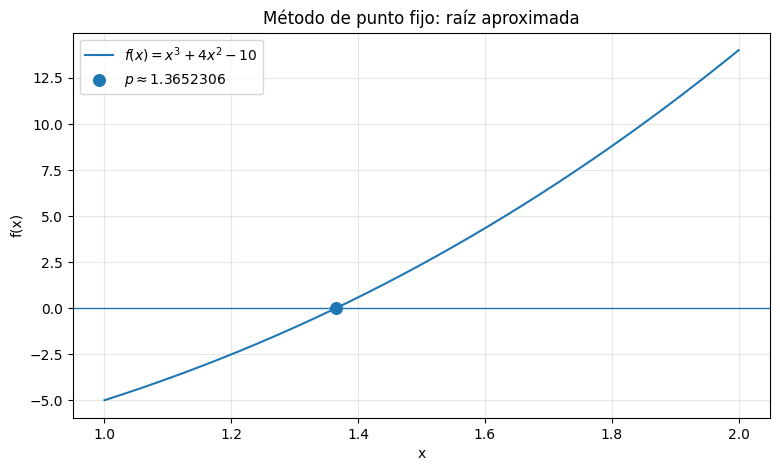

In [7]:

x = np.linspace(1, 2, 400)
y = f(x)

plt.figure(figsize=(9, 5))
plt.plot(x, y, label=r"$f(x)=x^3+4x^2-10$")
plt.axhline(0, linewidth=1)
plt.scatter([raiz_aprox], [f(raiz_aprox)], s=70,
            label=fr"$p\approx{raiz_aprox:.7f}$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Método de punto fijo: raíz aproximada")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 10. Gráfica de convergencia

Se observa cómo las aproximaciones se estabilizan al acercarse al punto fijo.


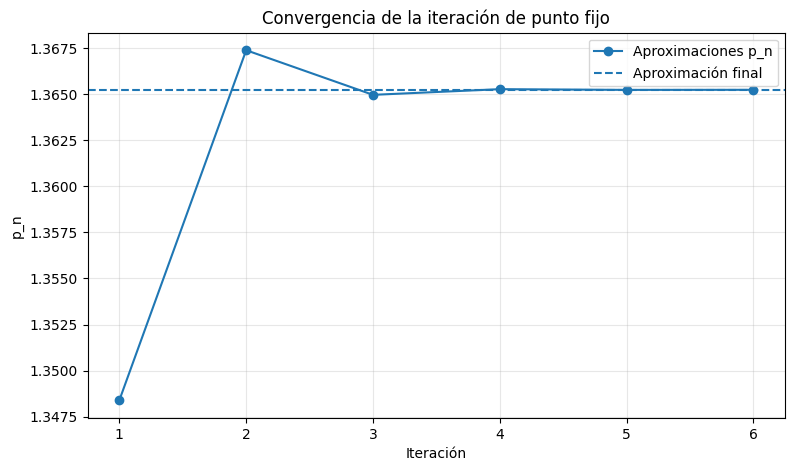

In [8]:

plt.figure(figsize=(9, 5))
plt.plot(tabla["iteración"], tabla["p actual"], marker="o",
         label="Aproximaciones p_n")
plt.axhline(raiz_aprox, linestyle="--", label="Aproximación final")
plt.xlabel("Iteración")
plt.ylabel("p_n")
plt.title("Convergencia de la iteración de punto fijo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 11. Resultado final y conclusión

La aproximación final es cercana a

\[
\boxed{p\approx 1.36523}.
\]

El cuaderno implementa el **Algoritmo 2.2 de Burden**: calcula \(p_n=g(p_{n-1})\), comprueba si \(|p_n-p_{n-1}|<TOL\) y actualiza la aproximación mientras sea necesario. La opción (d) converge para \(p_0=1.5\) y su punto fijo satisface la ecuación original \(x^3+4x^2-10=0\).
